### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
x0 : 0.0
y0 : 0.1
T : 12.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2025-04-09 13:27:08.651189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744198028.670110   21536 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744198028.675153   21536 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-09 13:27:08.689750: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 13:27:10.669262: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL

Model: "nested_PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,852 (30.67 KB)

 Trainable params: 7,852 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [3]:
training_log = PINN.train()

Training started...
    0/25000 | loss: 4.65e+00
 1000/25000 | loss: 1.03e-02
 2000/25000 | loss: 1.04e-02
 3000/25000 | loss: 4.70e-03
 4000/25000 | loss: 4.74e-03
 5000/25000 | loss: 4.18e-03
 6000/25000 | loss: 5.11e-03
 7000/25000 | loss: 4.50e-03
 8000/25000 | loss: 4.61e-03
 9000/25000 | loss: 3.24e-03
10000/25000 | loss: 1.56e-03
11000/25000 | loss: 2.30e-03
12000/25000 | loss: 2.08e-03
13000/25000 | loss: 4.34e-05
14000/25000 | loss: 1.86e-06
15000/25000 | loss: 1.24e-05
16000/25000 | loss: 1.23e-06
17000/25000 | loss: 8.65e-07
18000/25000 | loss: 3.36e-05
19000/25000 | loss: 9.41e-06
20000/25000 | loss: 5.70e-07
21000/25000 | loss: 2.24e-06
22000/25000 | loss: 3.84e-05
23000/25000 | loss: 5.40e-07
24000/25000 | loss: 7.48e-06
------------
logs/default
*** logs saved ***
### Training finished ###


# Plot Section

In [4]:
from model.plots import learning_curves, toy_example_dynamics, loss_over_tcoll, plot_regularization, plot_toy_example_direction, plot_regularization_over_domain

### Learning Curves

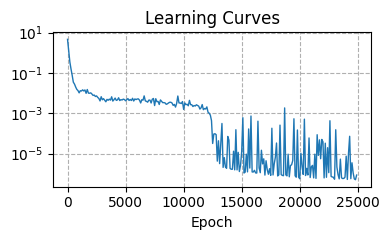

In [5]:
learning_curves(training_log)

### Toy Example Dynamics

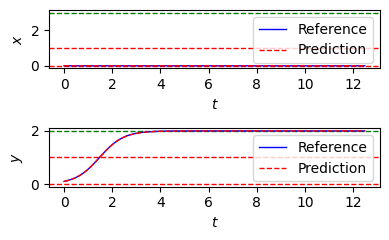

In [6]:
toy_example_dynamics(PINN)

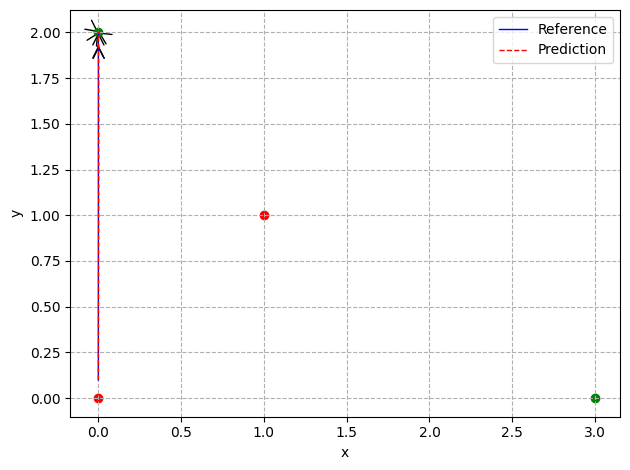

In [7]:
plot_toy_example_direction(PINN=PINN)

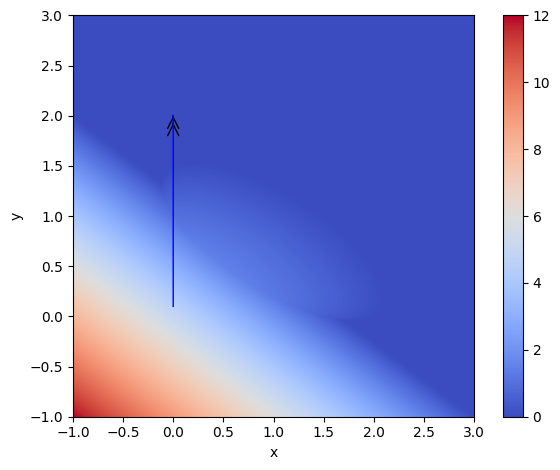

In [8]:
plot_regularization_over_domain(PINN=PINN)

(1250, 1)
(1250, 2)
TensorShape([1250])


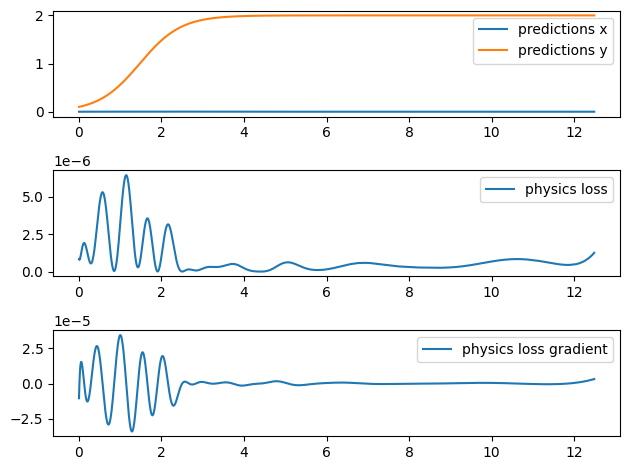

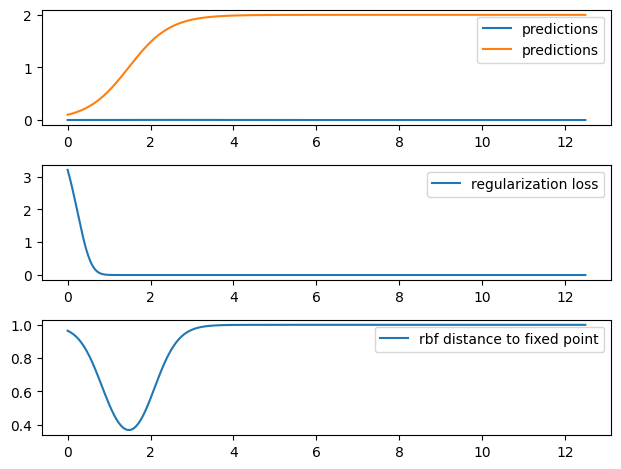

In [9]:
import tensorflow as tf

t_col = PINN.data.t_line()
pred = PINN(t_col)

print(t_col.shape)
print(pred.shape)

loss_over_tcoll(PINN)

plot_regularization(PINN)


(1250,)
(1250,)
(1250,)


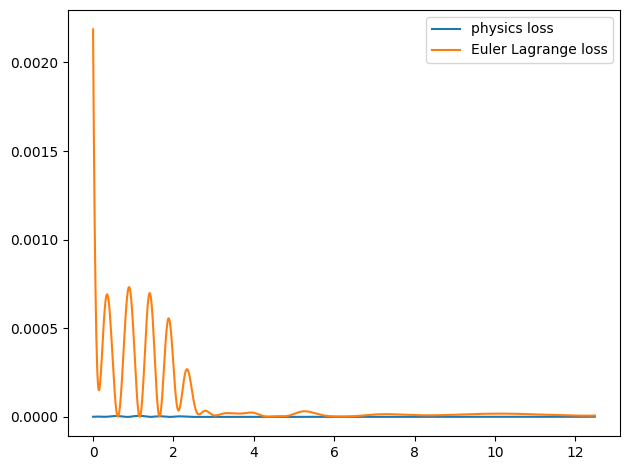

In [10]:
from model.plots import plot_EL_loss

plot_EL_loss(PINN)

### Training animation

In [11]:
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()

    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))
    
    # get reference solution (analytical)
    t_line, x_true, y_true = PINN.data.reference()
    # get PINN prediction
    preds = PINN(t_line)
    x_pred = preds[:, 0]
    y_pred = preds[:, 1]

    #############################
    ### Updated plot comes here
    #############################

    # include fixed points
    for x_fix, y_fix, col in [(0, 0, 'red'), (0, 2, 'green'), (3, 0, 'green'), (1, 1, 'red')]:
        ax.scatter(x_fix, y_fix, c=col)
    

    # make plots
    ax.plot(x_true, y_true, c='blue', lw=1, label='Reference')
    ax.plot(x_pred, y_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.legend()
    ax.set_ylabel(r'$y$')
    ax.set_xlabel(r'$t$')


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [12]:
import pandas as pd
import numpy as np
from model.plots import results_heatmap

results = pd.read_csv("results.csv")

results_heatmap(results)

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'

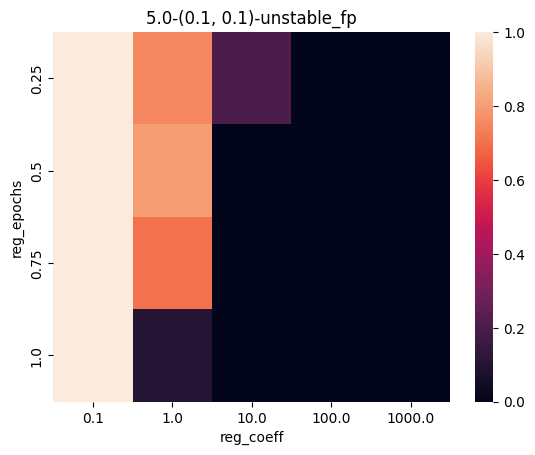

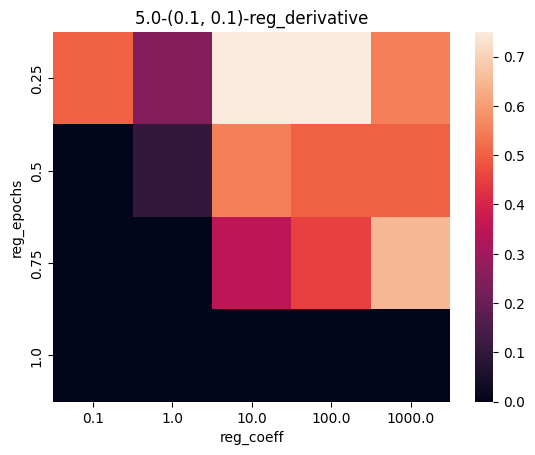

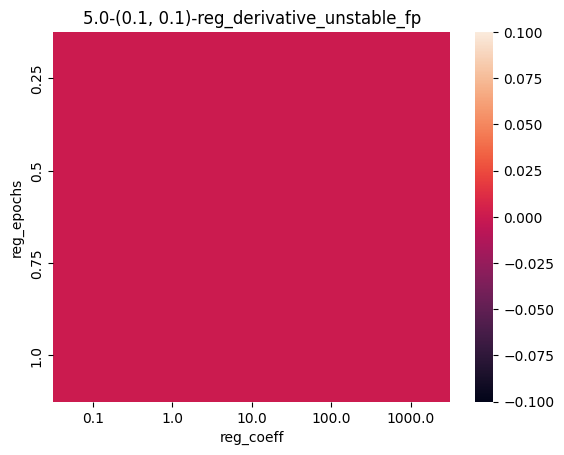

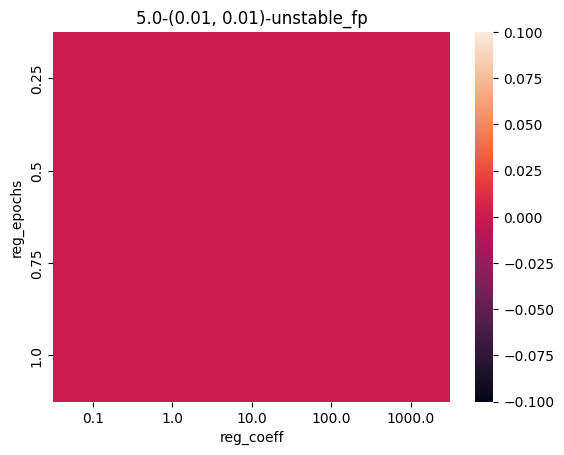

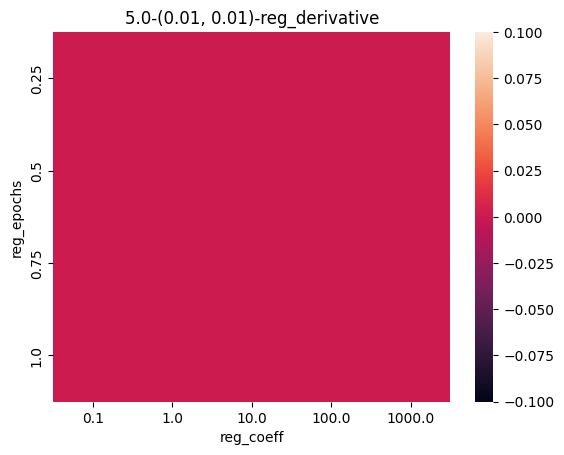

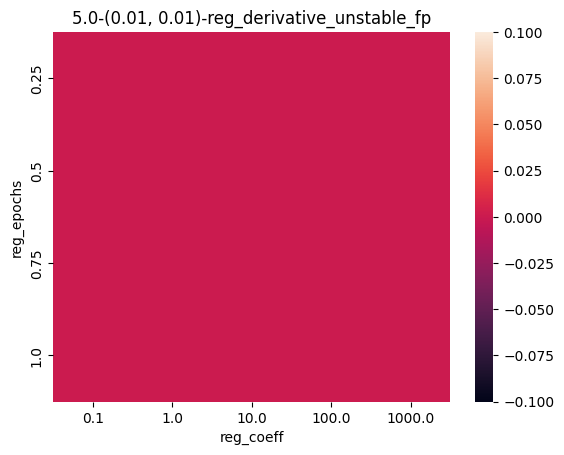

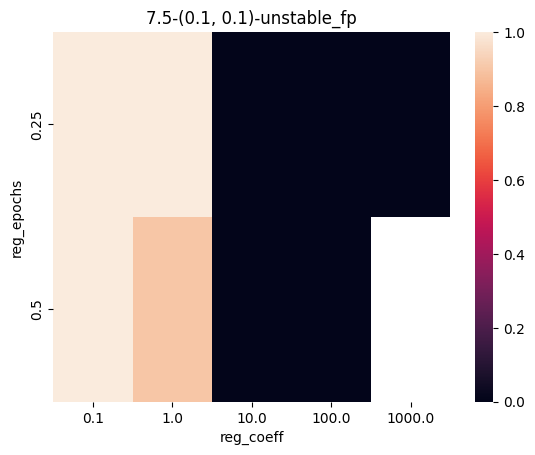

In [ ]:
from model.plots import results_linear_decay
import pandas as pd

results = pd.read_csv("results_linear_decay.csv")

results_linear_decay(results=results)



In [ ]:
import numpy as np

x0s = np.linspace(0.3, 0.4, 30)
y0s = np.linspace(0.4, 0.5, 30)

closest_init = None
min_dist = np.inf

for i in range(10):
    for j in range(10):
        config["x0"] = x0s[i]
        config["y0"] = y0s[j]
        PINN = PhysicsInformedNN(config)
        t_line, x_true, y_true = PINN.data.reference()
        dist = np.min((x_true - 1.0)**2 + (y_true - 1.0)**2)
        if dist < min_dist:
            min_dist = dist
            closest_init =  (x0s[i], y0s[j])

print(closest_init)

/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b